# Used Car - Analyzing what are the factors impacting the price
### We explored a dataset contained information on 426K used cars. Our goal is to understand what factors make a car more or less expensive. 

In [26]:
#import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import Lasso,Ridge,LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import seaborn as sns

In [3]:
#load dataset
df = pd.read_csv('vehicles.csv')

In [4]:
#verify dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

In [5]:
#Print fist few records
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


# 1. Data Preparation
### Filter price between 500 and 100,000
### Filter odometer rating between 1 and 300,000
### Filter year > 1990

In [6]:
df = df[(df['price'] > 500) & (df['price'] < 100000)]
df = df[(df['odometer'] > 0) & (df['odometer'] < 300000)]
df = df[(df['year'] > 1990)]

In [7]:
#print first few records
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
27,7316814884,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,3GTP1VEC4EG551563,NaN,NaN,pickup,white,al
28,7316814758,auburn,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,1GCSCSE06AZ123805,NaN,NaN,pickup,blue,al
29,7316814989,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,3GCPWCED5LG130317,NaN,NaN,pickup,red,al
30,7316743432,auburn,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,5TFRM5F17HX120972,NaN,NaN,pickup,red,al
31,7316356412,auburn,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,NaN,rwd,full-size,truck,black,al


In [42]:
#Select important features
features = ['year', 'manufacturer', 'condition', 'cylinders', 'fuel', 
                'odometer', 'title_status', 'transmission', 'drive', 'type']

#Retain only the important features and drop all other columns except price

df = df[features + ['price']].copy()

In [9]:
#Select random 50K records for training
# df = df.sample(n=min(50000,len(df)),random_state=42)

In [43]:
#create a dataframe without price

X = df.drop('price',axis=1)

#create a series with just price

y = df['price']

print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [44]:
# Define categorical and numerical groupings
categorical_features = ['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type']
numeric_features = ['year', 'odometer']

### numeric_transformer
This handles the missing data in the numeric_features. Missing values will be filled with median. StandardScaler is used to create Z scores as the years, odometer values are vastly different.

### categorical_transformer
This handles the missing data in categorical features. Missing values will be filled with most frequest values. Also create binary column for categories using OneHotEncoder.

In [45]:
# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])

# 2. Modeling and Evaluation
# We will be creating Linear, Ridge and Lasso regression models and compare them.
# Vehicles dataset is splited into 80/20 train and test data. 
# Best features and hyperparamenters are identified using GridSearchCV algorithm


In [46]:
#clf = Pipeline(steps=[('preprocessor', preprocessor),('classifier', Lasso(alpha=100, random_state=42))])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': {
        'model': Pipeline(steps=[('preprocessor',preprocessor),('regressor',LinearRegression())]),
        'params':{}
    },
    'Ridge Regression': {
        'model': Pipeline(steps=[('preprocessor',preprocessor),('regressor',Ridge(random_state=42))]),
        'params':{'regressor__alpha':[0.1,1,10,50,100,500]}
    },
    'Lasso Regression': {
        'model': Pipeline(steps=[('preprocessor',preprocessor),('regressor',Lasso(random_state=42))]),
        'params':{'regressor__alpha':[0.1,1,10,50,100,500]}
    }
}
results = []
model_coefs = {}

for name,config in models.items():
    print(f"Training {name} model")
    grid = GridSearchCV(config['model'],config['params'],cv=5,scoring='neg_mean_squared_error',n_jobs=-1)
    grid.fit(X_train,y_train)
    best_model = grid.best_estimator_
    # print("Best Model:",best_model)
    #Extract the features used in the model
    regressor = best_model.named_steps['regressor']
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    #Clean up the feature names to remove category or numeric prefix for presentation
    clean_feature_names = [f.replace('num__','').replace('cat__','').replace('_',' ').title() for f in feature_names]

    coef_df = pd.DataFrame({
        'Feature':clean_feature_names,
        'Coefficient':regressor.coef_
    })

    top_possitives = coef_df.sort_values(by='Coefficient',ascending=False).head(10)
    top_negatives = coef_df.sort_values(by='Coefficient',ascending=True).head(10)

    combined_coefs = pd.concat([top_possitives,top_negatives]).sort_values(by='Coefficient',ascending=False)

    #Tag for color coding
    combined_coefs['Impact'] = np.where(combined_coefs['Coefficient'] > 0, 'Positive','Negative')
    model_coefs[name] = combined_coefs
    
    y_pred = best_model.predict(X_test)
    r2=r2_score(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mae = mean_absolute_error(y_test,y_pred)
    best_params = grid.best_params_ if config['params'] else "None"
    results.append({
        'Model': name,
        'Best Alpha': best_params.get('regressor__alpha', 'N/A') if best_params != "None" else "N/A",
        'R2':r2,
        'RMSE':rmse,
        'MAE': mae
    })
results_df = pd.DataFrame(results)
print("\nModel Comparision:\n")
print(results_df.to_string(index=False))

Training Linear Regression model
Training Ridge Regression model
Training Lasso Regression model

Model Comparision:

            Model Best Alpha       R2        RMSE         MAE
Linear Regression        N/A 0.672479 8045.127172 5599.303100
 Ridge Regression          1 0.672460 8045.358061 5599.315995
 Lasso Regression          1 0.672156 8049.087939 5598.238845


# 3. Visualize Model Metrics
## Create bar plots to show R2 score, Root Mean Squared Error and Mean Absolute Errors for the 3 models
### $R^2$ Score:
It measures the percentage of variance in vehicle price that our model successfully explains based on the vehicle's features. A higher the number indicates better fit.
### Root Mean Squared Error
It heavily penalizes large pricing errors. It ensures we are choosing a model that minimizes the huge pricing mistakes. Misricing a luxury car by 10K USD has bigger impact than mispricing an economy car by $1000. 
### Mean Absolute Error
It represents the average dollar amount by which our predictions miss the actual vehicle price.

<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\sbrit\AppData\Local\Temp\ipykernel_32528\4214498429.py:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.savefig('images\model_comparision.png')


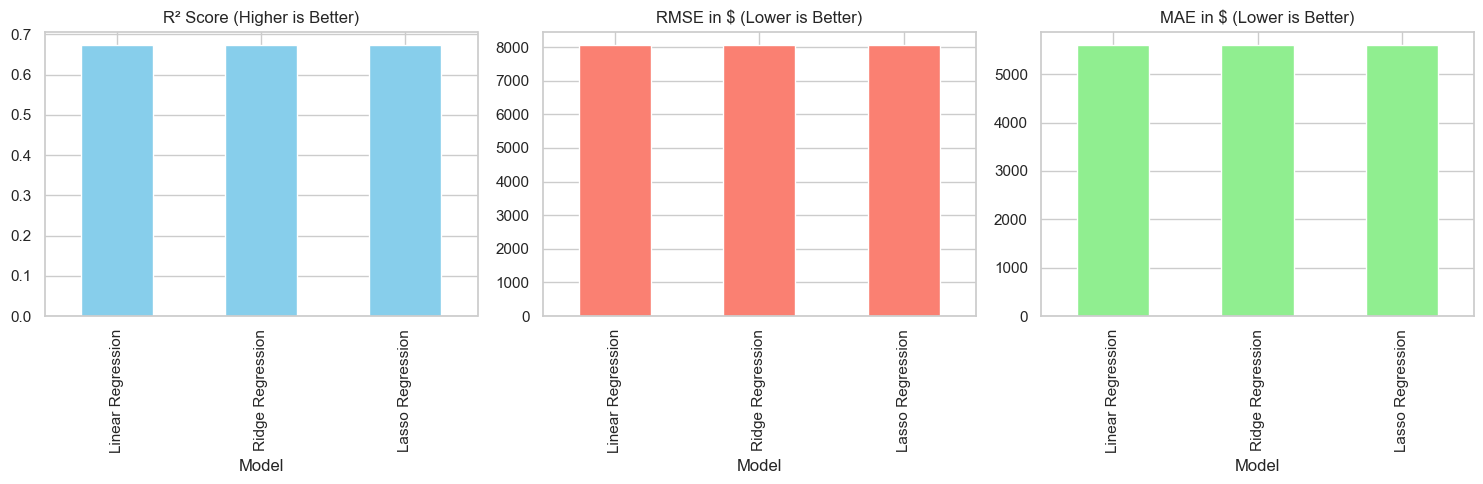

In [48]:
fig,axes = plt.subplots(1,3,figsize=(15,5))
results_df.plot(x='Model',y='R2',kind='bar',ax=axes[0],color='skyblue',title='R² Score (Higher is Better)',legend=False)
results_df.plot(x='Model',y='RMSE',kind='bar',ax=axes[1],color='salmon',title='RMSE in $ (Lower is Better)',legend=False)
results_df.plot(x='Model',y='MAE',kind='bar',ax=axes[2],color='lightgreen',title='MAE in $ (Lower is Better)',legend=False)
plt.tight_layout()
plt.savefig('images\model_comparision.png')

## Model Confidence (For dealership review)
All 3 models has uniform results as shown in the above plots. 
### $R^2$ Score
Our model provides a solid foundational baseline as highly effective ball park pricing tool. Our model can understand 67% of variation in used cars with the available data. Though we have the foundational key information about vehicles to capture the depreciation, 33% of important granular features are missing. Real world car valuation needs more intricate features like trim levels, vehicle history, local dynamics, demand, season etc.

### Root Mean Squared Error
Our model's price prediction is off by an average of $8000. We should keep this was heavily penalized by large outliers. This shows our model can predict economy cars reasonably well but not the high end luxury vehicles. 

### Mean Absolute Error
Our baseline pricing is off by $5600 on an average. This error margin exists because we use only the standard featuers and the real world pricing need more data like accessories, vehicle history etc.





# 4. Exploratory Data Analysis

<>:42: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:42: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\sbrit\AppData\Local\Temp\ipykernel_32528\1305872034.py:42: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.savefig('images\seaborn_eda_plots.png',dpi=300)
C:\Users\sbrit\AppData\Local\Temp\ipykernel_32528\1305872034.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x = 'condition',y='price',order=order_cond,ax = axes[0,1],palette='Set2')
C:\Users\sbrit\AppData\Local\Temp\ipykernel_32528\1305872034.py:28: FutureWa

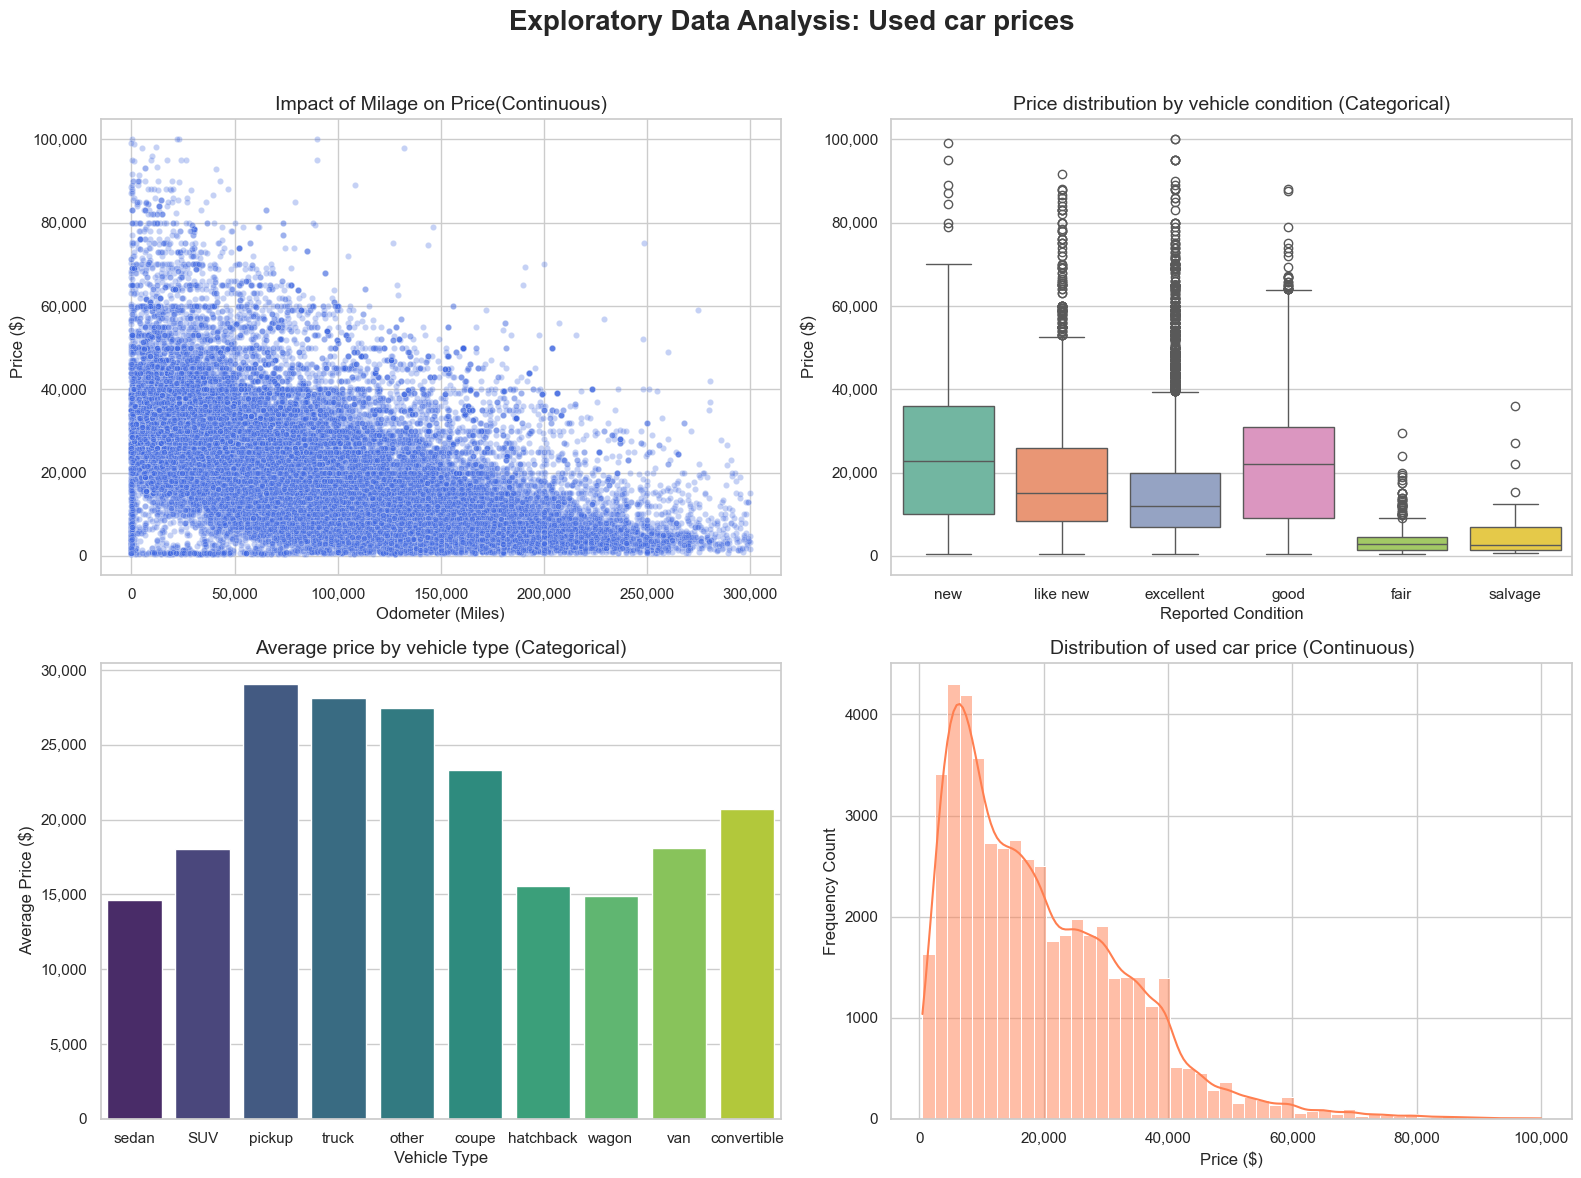

In [49]:
#set the viz style
sns.set_theme(style = "whitegrid")

#Create 2X2 grid
fig,axes = plt.subplots(2,2,figsize=(16,12))

#set the title
fig.suptitle('Exploratory Data Analysis: Used car prices',fontsize = 20,fontweight = 'bold',y=0.98)

#Plot Continuous vs Continuous: Odometer vs Price as scatter plot
sns.scatterplot(data=df,x = 'odometer',y='price',alpha=0.3,ax = axes[0,0],color = 'royalblue',s=20)
axes[0,0].set_title('Impact of Milage on Price(Continuous)',fontsize = 14)
axes[0,0].set_xlabel('Odometer (Miles)',fontsize = 12)
axes[0,0].set_ylabel('Price ($)',fontsize = 12)
axes[0,0].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[0,0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

#Plot Categorical vs Continuous: Condition vs Price as scatter plot
order_cond = ['new', 'like new', 'excellent', 'good', 'fair', 'salvage']
sns.boxplot(data=df,x = 'condition',y='price',order=order_cond,ax = axes[0,1],palette='Set2')
axes[0,1].set_title('Price distribution by vehicle condition (Categorical)',fontsize = 14)
axes[0,1].set_xlabel('Reported Condition',fontsize = 12)
axes[0,1].set_ylabel('Price ($)',fontsize = 12)
axes[0,1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

#Plot Categorical vs Continuous: Vehicle Type vs Price as scatter plot
top_types = df['type'].value_counts().nlargest(10).index
sns.barplot(data=df[df['type'].isin(top_types)],x = 'type',y='price',ax = axes[1,0],palette='viridis',estimator=np.mean,errorbar=None,order=top_types)
axes[1,0].set_title('Average price by vehicle type (Categorical)',fontsize = 14)
axes[1,0].set_xlabel('Vehicle Type',fontsize = 12)
axes[1,0].set_ylabel('Average Price ($)',fontsize = 12)
axes[1,0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

#Plot continuous price distribution
sns.histplot(data=df,x='price',bins=50,kde=True,ax=axes[1,1],color='coral')
axes[1,1].set_title('Distribution of used car price (Continuous)',fontsize=14)
axes[1,1].set_xlabel('Price ($)',fontsize=12)
axes[1,1].set_ylabel('Frequency Count',fontsize=12)
axes[1,1].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('images\seaborn_eda_plots.png',dpi=300)
# plt.show()


# 5. Visualize model predictions
## Seaborn plot shows the top categories that influence both positively and negatively the used car price

<>:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\sbrit\AppData\Local\Temp\ipykernel_32528\2655397215.py:20: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.savefig('images\price_impact_plots.png',bbox_inches='tight')


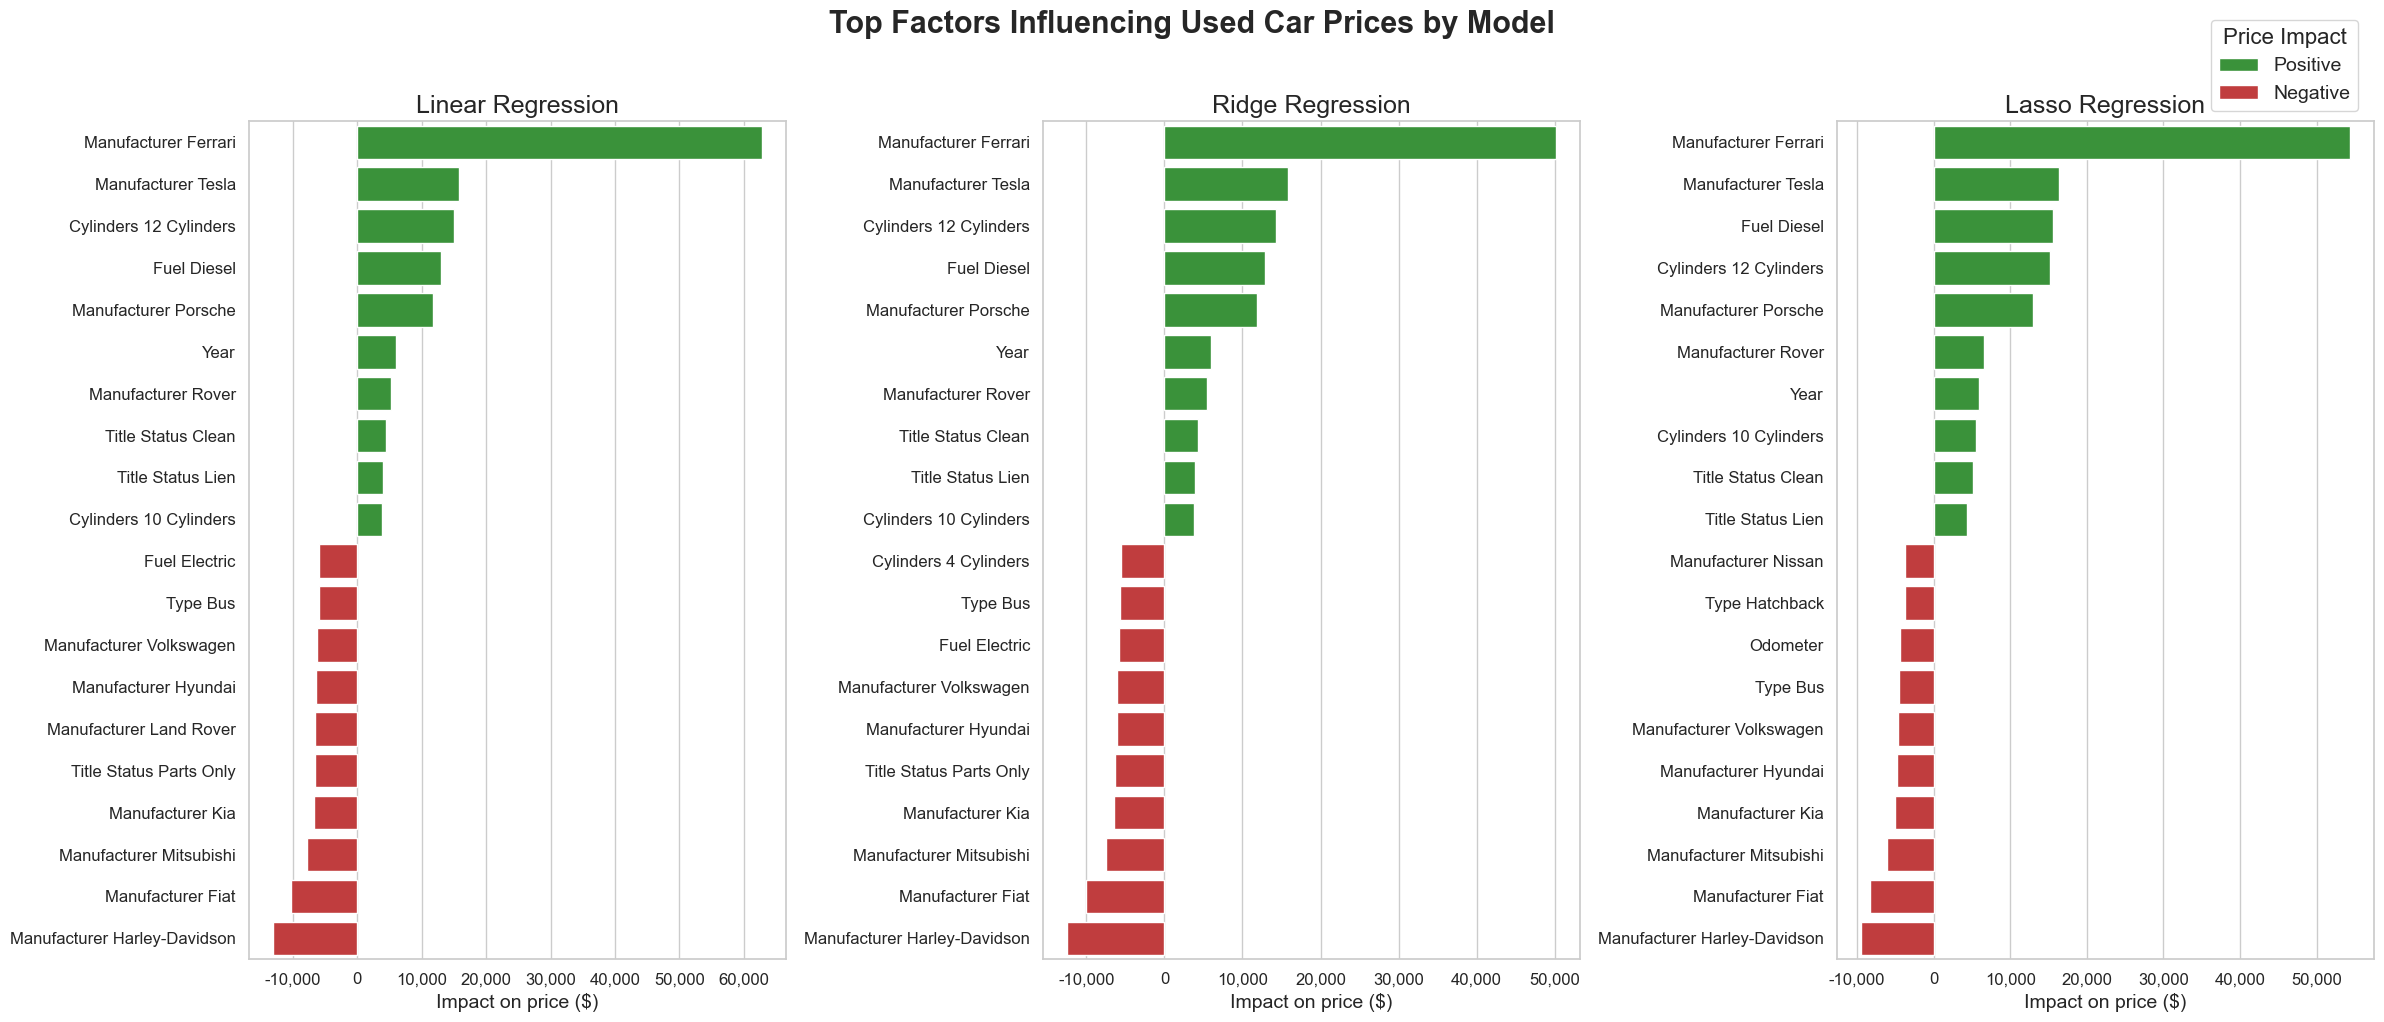

In [50]:
#create a 1 row 3 col subplot
sns.set_theme(style='whitegrid')
fig,axes = plt.subplots(1,3,figsize=(24,10))
fig.suptitle('Top Factors Influencing Used Car Prices by Model',fontsize=22,fontweight='bold',y=1.02)

for i, (name,coef_df) in enumerate(model_coefs.items()):
    ax=axes[i]
    sns.barplot(data=coef_df,x='Coefficient',y='Feature',hue='Impact',palette={'Positive':'#2ca02c','Negative':'#d62728'},ax=ax,dodge=False)
    ax.set_title(f'{name}',fontsize=18)
    ax.set_xlabel('Impact on price ($)',fontsize=14)
    ax.set_ylabel('')
    ax.tick_params(axis='y',labelsize=12)
    ax.tick_params(axis='x',labelsize=12)
    ax.get_legend().remove()
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

handles,labels = ax.get_legend_handles_labels()
fig.legend(handles,labels,loc='upper right',title='Price Impact',fontsize=14,title_fontsize=16,bbox_to_anchor=(0.99,1.02))
plt.tight_layout()
plt.savefig('images\price_impact_plots.png',bbox_inches='tight')



# 6. Report
## Best Model
Out of the 3 model plots shown above, Lasso Regression results looks promising though the performance metrics are not very different between 3 models. Highlights of the predictions are as follows.

## Key factors impacting price positively
1. Brand - Ferrari and Tesla has a very good resale price.
2. Size of the engine and pickup trucks also has a positive impact
3. Diesel engines are the most popular feature, customers were ready to pay 12K more.
4. Followed by year manufactured as expected the latest cars has big impact in the price
5. Clean title cars are 3K more 

## Key factors impacting price negatively

1. Brand - Harley, Fiat, Mitsubishi, Kia has very less demand.
2. Followed by odometer. As expected the cars driven the most will loose value.
4. Bus and electric cars are less popular

## Recommendations to customer (Used car dealership)

| Action | Recommendation | Justification |
|--------|----------------|---------------|
|Prioritize | AWD, Trucks & Pickups | Combination of these vehicles provide the highest profit marigin |
|Target | Diesel Vehicles | Diesel trucks or SUVs have highest consumer demand |
|Avoid / Limit | High milage FWD sedans / hatchbacks | These vehicles lost lot of values and margin will be very low. |
|Brand Focus | Tesla, Ferrari | Tesla, Ferrari vehicles has good resale price whereas Kia and Hyundai lost lot of values.

## Next steps
Upgrade the underlying data availability, consider using the vehicle history from Carfax, current market dynamics from KBB.